In [1]:
import pandas as pd
import numpy as np
import os
import pickle
from scipy.stats import pearsonr, spearmanr
os.chdir('../..')


In [2]:
os.getcwd()

'/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency'

In [3]:
orig = pd.read_csv('output/data/sanityCheck/originalSeqs_predictions.csv') # checks the impact of the sequences on predictions (extraFeatures the same for all sequences)
same = pd.read_csv('output/data/sanityCheck/sameSeq_predictions.csv') # checks the impact of the extraFeatures on predictions (sequence the same for all extraFeatures)
utr5 = pd.read_csv('output/data/sanityCheck/same5UTR_predictions.csv') # checks the impact of the 3' UTR on predictions (5' UTR and extraFeatures the same for all while 3' UTR are the originals)
utr3 = pd.read_csv('output/data/sanityCheck/same3UTR_predictions.csv') # checks the impact of the 5' UTR on predictions (3' UTR and extraFeatures the same for all while 5' UTR are the originals)

# merge the two dataframes on sequenceCounts
merged = pd.merge(orig, same, on='sequenceCount', suffixes=('_orig', '_same'), how='outer')
merged = pd.merge(merged, utr5, on='sequenceCount', suffixes=('', '_utr5'), how='outer')
merged = pd.merge(merged, utr3, on='sequenceCount', suffixes=('', '_utr3'), how='outer')

In [4]:
merged

,actualDecayRate_orig,predictedDecayRate_orig,sequenceCount,actualDecayRate_same,predictedDecayRate_same,actualDecayRate,predictedDecayRate,actualDecayRate_utr3,predictedDecayRate_utr3
0,0.53,0.39,1,0.53,0.39,0.53,0.39,0.53,0.39
1,0.53,0.39,2,0.62,0.52,0.53,0.35,0.53,0.40
2,0.53,0.52,3,0.72,0.37,0.53,0.53,0.53,0.43
3,0.53,0.53,4,0.37,0.56,0.53,0.56,0.53,0.39
4,0.53,0.66,5,0.75,0.46,0.53,0.57,0.53,0.45
...,...,...,...,...,...,...,...,...,...
905,NaN,NaN,60,0.39,0.39,NaN,NaN,0.53,0.42
906,NaN,NaN,295,0.29,0.40,NaN,NaN,0.53,0.44
907,NaN,NaN,574,0.51,0.46,NaN,NaN,0.53,0.37
908,NaN,NaN,627,0.83,0.63,NaN,NaN,0.53,0.44


In [5]:
importance = pickle.load(open('output/importance/shap.pkl', 'rb'))


In [6]:
counts = [x+1 for x in range(len(importance))]
actualPredictions = [imp.text.split(' ')[1].split(':')[1] for imp in importance]

ap = pd.DataFrame({'sequenceCount': counts, 'actualPredictions': actualPredictions})

# merge combined with ap
merged_df = pd.merge(ap, merged, on='sequenceCount', suffixes=('_ap',''), how='outer')

In [7]:
merged_df

,sequenceCount,actualPredictions,actualDecayRate_orig,predictedDecayRate_orig,actualDecayRate_same,predictedDecayRate_same,actualDecayRate,predictedDecayRate,actualDecayRate_utr3,predictedDecayRate_utr3
0,1,0.36,0.53,0.39,0.53,0.39,0.53,0.39,0.53,0.39
1,2,0.85,0.53,0.39,0.62,0.52,0.53,0.35,0.53,0.40
2,3,0.72,0.53,0.52,0.72,0.37,0.53,0.53,0.53,0.43
3,4,0.75,0.53,0.53,0.37,0.56,0.53,0.56,0.53,0.39
4,5,0.74,0.53,0.66,0.75,0.46,0.53,0.57,0.53,0.45
...,...,...,...,...,...,...,...,...,...,...
4208,4209,0.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4209,4210,0.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4210,4211,0.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4211,4212,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
print(merged_df[['actualPredictions','predictedDecayRate_orig','predictedDecayRate_same','predictedDecayRate','predictedDecayRate_utr3']].to_numpy().T)

[['0.36' '0.85' '0.72' ... '0.37' '0.4' '0.3']
 [0.39 0.39 0.52 ... nan nan nan]
 [0.39 0.52 0.37 ... nan nan nan]
 [0.39 0.35 0.53 ... nan nan nan]
 [0.39 0.4 0.43 ... nan nan nan]]


In [ ]:
# Convert 'actualPredictions' column to numeric, coercing errors to NaN
merged_df['actualPredictions'] = pd.to_numeric(merged_df['actualPredictions'], errors='coerce')

# Now calculate and print the mean of the absolute difference with interpretable labels
print("(impact of extraFeature) impact of extraFeatures compared to sequence predictions:")
print(f"  {np.mean(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_orig'])):.4f}")
#print("(impact of seq) impact of extraFeatures compared to extraFeatures predictions:")
#print(f"  {np.mean(abs(merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate_orig'])):.4f}")

print("\n(impact of seq) impact of sequences compared to extraFeatures predictions:")
print(f"  {np.mean(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_same'])):.4f}")
#print("(impact of extraF) impact of sequences compared to sequence predictions:")
#print(f"  {np.mean(abs(merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate_same'])):.4f}")

print("\n(impact of 5UTR) :")
print(f"  {np.mean(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate'])):.4f}")
#print("(impact of EF and 3UTR) impact of 3'UTR compared to extraFeatures predictions:")
#print(f"  {np.mean(abs(merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate'])):.4f}")

print("\n(impact of 3UTR) :")
print(f"  {np.mean(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_utr3'])):.4f}")
#print("(impact of EF and 5UTR) impact of 5'UTR:")
#print(f"  {np.mean(abs(merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate_utr3'])):.4f}")

#print("\n\nsum of 3'UTR and 5'UTR impact:")
#print(f"  {np.mean(abs(merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate_utr3']) + abs(merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate'])):.4f}")

(impact of extraFeature) impact of extraFeatures compared to sequence predictions:
  0.1629

(impact of seq) impact of sequences compared to extraFeatures predictions:
  0.1490

(impact of 5UTR) impact of 3'UTR compared to sequence predictions:
  0.1509

(impact of 3UTR) impact of 5'UTR compared to sequence predictions:
  0.1421


In [21]:
# Convert 'actualPredictions' column to numeric, coercing errors to NaN
merged_df['actualPredictions'] = pd.to_numeric(merged_df['actualPredictions'], errors='coerce')

# Now calculate and print the mean of the olute difference with interpretable labels
print("(impact of extraFeature) impact of extraFeatures compared to sequence predictions:")
print(f"  {np.mean((merged_df['actualPredictions'] - merged_df['predictedDecayRate_orig'])):.4f}")
#print("(impact of seq) impact of extraFeatures compared to extraFeatures predictions:")
#print(f"  {np.mean((merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate_orig'])):.4f}")

print("\n(impact of seq) impact of sequences compared to extraFeatures predictions:")
print(f"  {np.mean((merged_df['actualPredictions'] - merged_df['predictedDecayRate_same'])):.4f}")
#print("(impact of extraF) impact of sequences compared to sequence predictions:")
#print(f"  {np.mean((merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate_same'])):.4f}")

print("\n(impact of 5UTR) :")
print(f"  {np.mean((merged_df['actualPredictions'] - merged_df['predictedDecayRate'])):.4f}")
#print("(impact of EF and 3UTR) impact of 3'UTR compared to extraFeatures predictions:")
#print(f"  {np.mean((merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate'])):.4f}")

print("\n(impact of 3UTR) :")
print(f"  {np.mean((merged_df['actualPredictions'] - merged_df['predictedDecayRate_utr3'])):.4f}")

(impact of extraFeature) impact of extraFeatures compared to sequence predictions:
  0.0710

(impact of seq) impact of sequences compared to extraFeatures predictions:
  0.0417

(impact of 5UTR) :
  0.0866

(impact of 3UTR) :
  0.0940


In [16]:
# Convert 'actualPredictions' column to numeric, coercing errors to NaN
merged_df['actualPredictions'] = pd.to_numeric(merged_df['actualPredictions'], errors='coerce')

# Now calculate and print the median of the absolute difference with interpretable labels
print("(impact of extraFeature) impact of extraFeatures compared to sequence predictions:")
print(f"  {np.median(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_orig']).dropna()):.4f}")

print("\n(impact of seq) impact of sequences compared to extraFeatures predictions:")
print(f"  {np.median(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_same']).dropna()):.4f}")

print("\n(impact of 5UTR) :")
print(f"  {np.median(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate']).dropna()):.4f}")

print("\n(impact of 3UTR) :")
print(f"  {np.median(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_utr3']).dropna()):.4f}")


(impact of extraFeature) impact of extraFeatures compared to sequence predictions:
  0.1300

(impact of seq) impact of sequences compared to extraFeatures predictions:
  0.1100

(impact of 5UTR) :
  0.1100

(impact of 3UTR) :
  0.1000


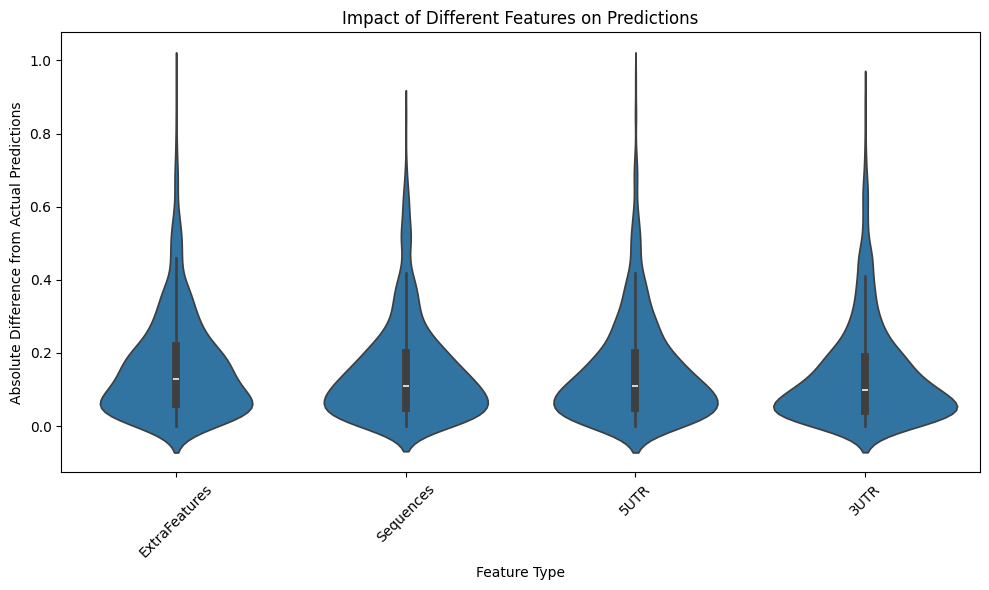

In [27]:
import seaborn as sns

import matplotlib.pyplot as plt

# Prepare data for swarm plot
impact_data = []

# Calculate impacts and add to list
impact_extraFeatures = abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_orig']).dropna()
impact_sequences = abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_same']).dropna()
impact_5UTR = abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate']).dropna()
impact_3UTR = abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_utr3']).dropna()

# Create dataframe for plotting
plot_data = pd.DataFrame({
    'Impact': list(impact_extraFeatures) + list(impact_sequences) + list(impact_5UTR) + list(impact_3UTR),
    'Feature': ['ExtraFeatures'] * len(impact_extraFeatures) + 
               ['Sequences'] * len(impact_sequences) + 
               ['5UTR'] * len(impact_5UTR) + 
               ['3UTR'] * len(impact_3UTR)
})

# Create swarm plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=plot_data, x='Feature', y='Impact')
plt.title('Impact of Different Features on Predictions')
plt.ylabel('Absolute Difference from Actual Predictions')
plt.xlabel('Feature Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
import seaborn as sns

import matplotlib.pyplot as plt

# Prepare data for swarm plot
impact_data = []

# Calculate impacts and add to list
impact_extraFeatures = (merged_df['actualPredictions'] - merged_df['predictedDecayRate_orig']).dropna()
impact_sequences = (merged_df['actualPredictions'] - merged_df['predictedDecayRate_same']).dropna()
impact_5UTR = (merged_df['actualPredictions'] - merged_df['predictedDecayRate']).dropna()
impact_3UTR = (merged_df['actualPredictions'] - merged_df['predictedDecayRate_utr3']).dropna()

# Create dataframe for plotting
plot_data = pd.DataFrame({
    'Impact': list(impact_extraFeatures) + list(impact_sequences) + list(impact_5UTR) + list(impact_3UTR),
    'Feature': ['ExtraFeatures'] * len(impact_extraFeatures) + 
               ['Sequences'] * len(impact_sequences) + 
               ['5UTR'] * len(impact_5UTR) + 
               ['3UTR'] * len(impact_3UTR)
})


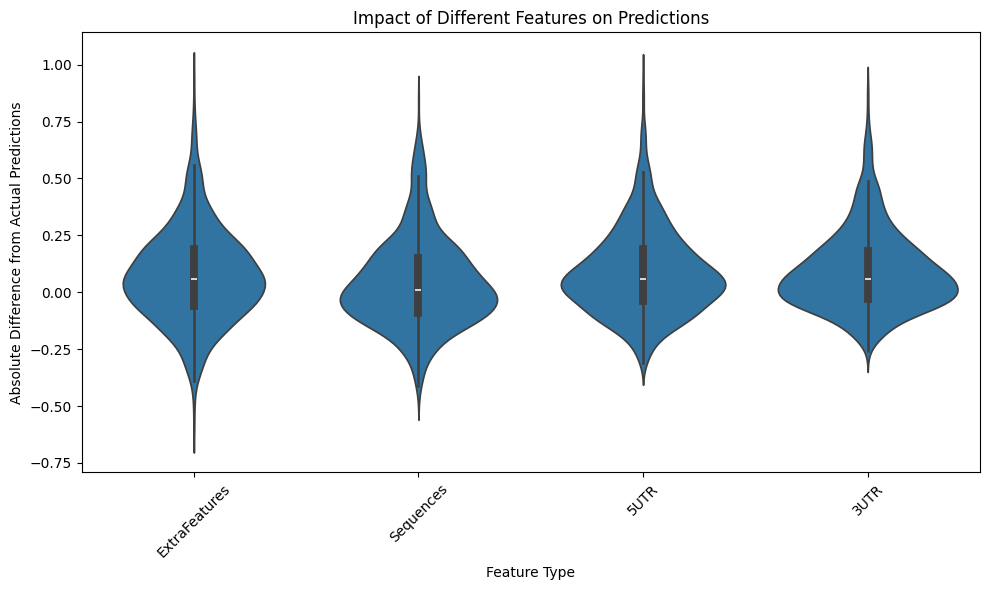

In [20]:

# Create swarm plot
plt.figure(figsize=(10, 6))
#sns.swarmplot(data=plot_data, x='Feature', y='Impact', size=3)
sns.violinplot(data=plot_data, x='Feature', y='Impact')
plt.title('Impact of Different Features on Predictions')
plt.ylabel('Absolute Difference from Actual Predictions')
plt.xlabel('Feature Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()